In [3]:
print("Hello Khushi")

Hello Khushi


In [4]:
import pandas as pd

In [5]:
import sys
print(sys.executable)

D:\Projects\Spam_classifier_detection\venv\Scripts\python.exe


In [6]:
!pip list

Package                   Version
------------------------- -----------
altair                    6.2.1
anyio                     4.14.0
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
async-lru                 2.3.0
attrs                     26.1.0
babel                     2.18.0
beautifulsoup4            4.15.0
bleach                    6.4.0
blinker                   1.9.0
cachetools                7.1.4
certifi                   2026.6.17
cffi                      2.0.0
charset-normalizer        3.4.7
click                     8.4.1
colorama                  0.4.6
comm                      0.2.3
contourpy                 1.3.3
cycler                    0.12.1
debugpy                   1.8.21
decorator                 5.3.1
defusedxml                0.7.1
executing                 2.2.1
fastjsonschema            2.21.2
fonttools                 4.63.0
fqdn                      1.5.1
gitdb             

In [7]:
import sys
!{sys.executable} -m pip install pandas numpy scikit-learn nltk matplotlib seaborn streamlit joblib


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import pandas as pd
import numpy as np

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Pandas version: 3.0.3
NumPy version: 2.4.6


In [9]:
import pandas as pd

In [10]:
df = pd.read_csv("../data/spam.csv", encoding ="latin-1")

In [11]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [12]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 677.1 KB


In [14]:
df.shape

(5572, 5)

In [15]:
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace = True)

In [16]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [17]:
df.rename(columns={'v1':'target', 'v2':'message'}, inplace=True)

In [18]:
df.head()

,target,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [19]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

In [20]:
df.head()

,target,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [21]:
df.isnull().sum()

target     0
message    0
dtype: int64

In [22]:
df.duplicated().sum()

np.int64(403)

In [23]:
df = df.drop_duplicates(keep='first')

In [24]:
df.shape

(5169, 2)

In [25]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

In [26]:
df['target'].value_counts(normalize=True) * 100

target
0    87.366996
1    12.633004
Name: proportion, dtype: float64

In [27]:
df['num_characters'] = df['message'].apply(len)

In [28]:
df['num_words'] = df['message'].apply(lambda x: len(x.split()))

In [29]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [30]:
from nltk.tokenize import sent_tokenize

df['num_sentences'] = df['message'].apply(
    lambda x: len(sent_tokenize(x))
)

In [31]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [32]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [33]:
from nltk.tokenize import sent_tokenize
df['num_sentences'] = df['message'].apply(lambda x: len(sent_tokenize(x)))

In [34]:
df.head()

,target,message,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,20,2
1,0,Ok lar... Joking wif u oni...,29,6,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,2
3,0,U dun say so early hor... U c already then say...,49,11,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,1


In [35]:
import string 
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

In [36]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [37]:
ps = PorterStemmer()

In [38]:
ps.stem("running")

'run'

In [39]:
def transform_text(text):
    #Covert to lowercase
    text = text.lower()

    #Tokenization
    text = nltk.word_tokenize(text)

    y = []

    #keep only alphanumeric words
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    #Remove stopwords and punctuation
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    #Stemming
    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)

In [40]:
transform_text("Hello!!! How are you doing today?")

'hello today'

In [41]:
df['transformed_text'] = df['message'].apply(transform_text)

In [42]:
df[['message', 'transformed_text']].head()

,message,transformed_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [44]:
tfidf = TfidfVectorizer(max_features=3000)

In [45]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [46]:
y = df['target'].values

In [47]:
X.shape

(5169, 3000)

In [48]:
from sklearn.model_selection import train_test_split

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [50]:
from sklearn.naive_bayes import MultinomialNB

In [51]:
model = MultinomialNB()

In [52]:
model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3627., 508.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.13,-2.1 ]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 3000)","[[ 0. , 0. , 0. ,..., 0. , 0.94,15.44], [ 0.65, 0.81, 0.33,..., 0.9 , 0. , 0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 3000)","[[-9.34,-9.34,-9.34,...,-9.34,-8.68,-6.54], [-7.95,-7.86,-8.16,...,-7.81,-8.45,-8.45]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3000


In [53]:
y_pred = model.predict(X_test)

In [54]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [55]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Prediction:", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy: 0.9729206963249516
Prediction: 0.9915966386554622
Recall : 0.8137931034482758
F1 Score : 0.8939393939393939


In [56]:
X.shape

(5169, 3000)

In [57]:
y_pred = model.predict(X_test)

In [58]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy:  0.9729206963249516
Precision:  0.9915966386554622
Recall : 0.8137931034482758
F1 Score: 0.8939393939393939


In [59]:
import joblib

joblib.dump(tfidf, "../models/vectorizer.pkl")
joblib.dump(model, "../models/model.pkl")

['../models/model.pkl']

In [60]:
import os
os.listdir("../models")

['model.pkl', 'vectorizer.pkl']

In [61]:
def predict_spam(text):
    transformed = transform_text(text)
    vectore_input = tfidf.transform([transformed])
    prediction = model.predict(vectore_input)[0]
    if prediction == 1:
        return "SPAM"
    else:
        return "HAM"

In [62]:
predict_spam("Congratulations! You have won a free iPhone. Click here now!")

'SPAM'

In [63]:
predict_spam("Hey Khushi!, are you free for class tomorrow?")

'HAM'

In [67]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[888   1]
 [ 27 118]]


In [66]:
df.head()

,target,message,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,20,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,6,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,11,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,1,nah think goe usf live around though


In [68]:
import seaborn as sns

In [69]:
import matplotlib.pyplot as plt

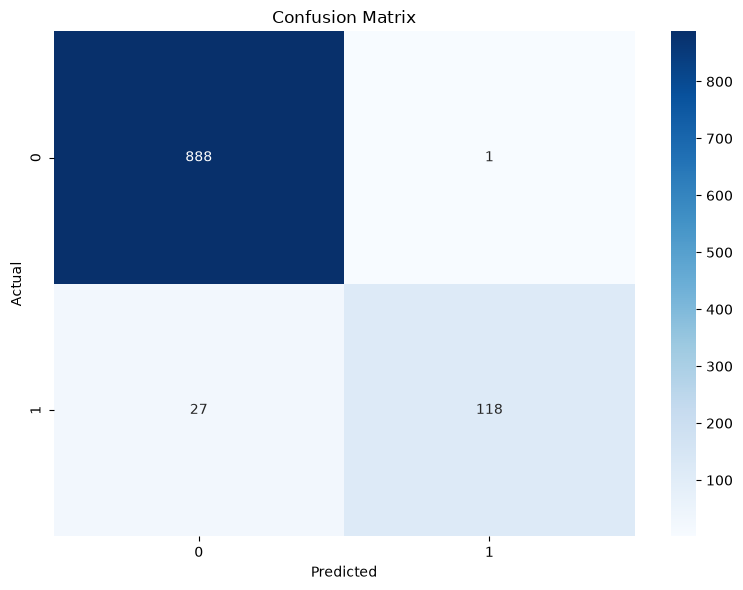

In [77]:
plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

In [78]:
!pip install wordcloud


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


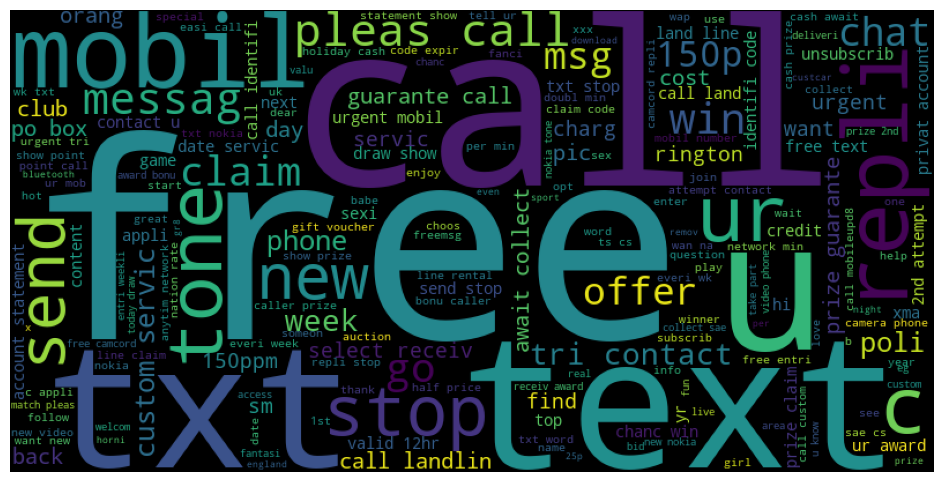

In [82]:
from wordcloud import WordCloud
spam_words = df[df['target']==1]['transformed_text'].str.cat(sep=" ")

wc = WordCloud(
    width=800,
    height=400,
    background_color='black'
)

spam_wc = wc.generate(spam_words)

plt.figure(figsize=(12,6))
plt.imshow(spam_wc)
plt.axis("off")
plt.show()

In [84]:
from collections import Counter

spam_corpus = []

for msgs in df[df['target']==1]['transformed_text']:
    for word in msgs.split():
        spam_corpus.append(word)

Counter(spam_corpus).most_common(30)

[('call', 320),
 ('free', 191),
 ('2', 155),
 ('txt', 141),
 ('text', 122),
 ('u', 119),
 ('ur', 119),
 ('mobil', 114),
 ('stop', 104),
 ('repli', 103),
 ('claim', 98),
 ('4', 97),
 ('prize', 82),
 ('get', 74),
 ('new', 64),
 ('servic', 64),
 ('tone', 63),
 ('send', 60),
 ('urgent', 57),
 ('nokia', 57),
 ('contact', 56),
 ('award', 55),
 ('phone', 52),
 ('cash', 51),
 ('pleas', 51),
 ('week', 49),
 ('win', 48),
 ('c', 45),
 ('collect', 45),
 ('min', 45)]

In [85]:
import pandas as pd

top_spam = pd.DataFrame(
    Counter(spam_corpus).most_common(30),
    columns=['word','count']
)
top_spam.head()


,word,count
0,call,320
1,free,191
2,2,155
3,txt,141
4,text,122


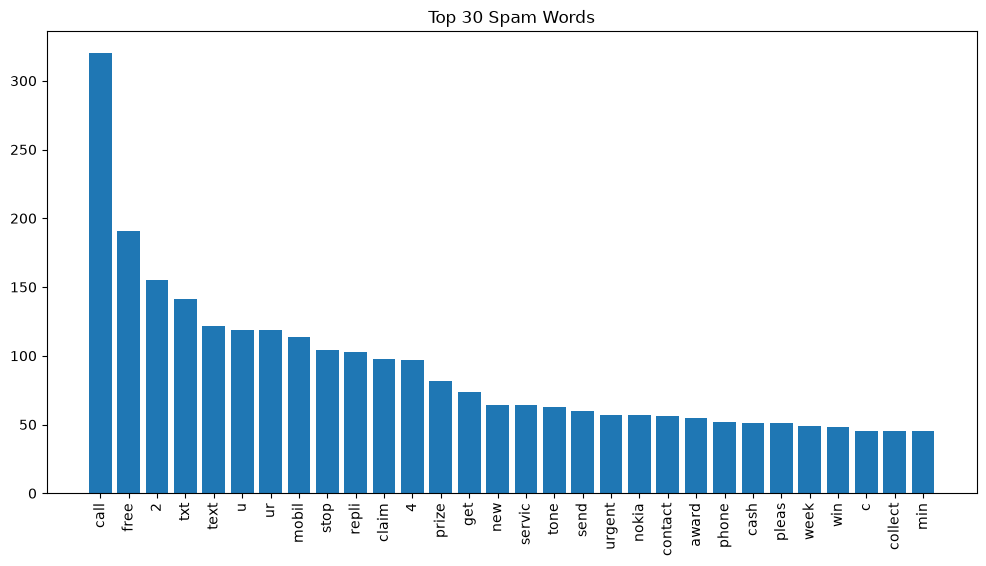

In [87]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))

plt.bar(
    top_spam['word'],
    top_spam['count']
)
plt.xticks(rotation=90)
plt.title("Top 30 Spam Words")
plt.show()

In [88]:
ham_corpus = []

for msgs in df[df['target']==0]['transformed_text']:
    for word in msgs.split():
        ham_corpus.append(word)

Counter(ham_corpus).most_common(30)

[('u', 883),
 ('go', 404),
 ('get', 349),
 ('gt', 288),
 ('lt', 287),
 ('2', 284),
 ('come', 275),
 ('got', 236),
 ('know', 236),
 ('like', 234),
 ('call', 233),
 ('time', 219),
 ('ok', 217),
 ('love', 216),
 ('good', 213),
 ('want', 208),
 ('ur', 197),
 ('day', 190),
 ('need', 170),
 ('one', 165),
 ('lor', 159),
 ('4', 156),
 ('home', 152),
 ('think', 149),
 ('see', 147),
 ('take', 143),
 ('still', 143),
 ('da', 142),
 ('tell', 133),
 ('make', 129)]

In [89]:
ham_df = pd.DataFrame(
    Counter(ham_corpus).most_common(20),
    columns=['words','count']
)
ham_df

,words,count
0,u,883
1,go,404
2,get,349
3,gt,288
4,lt,287
5,2,284
6,come,275
7,got,236
8,know,236
9,like,234


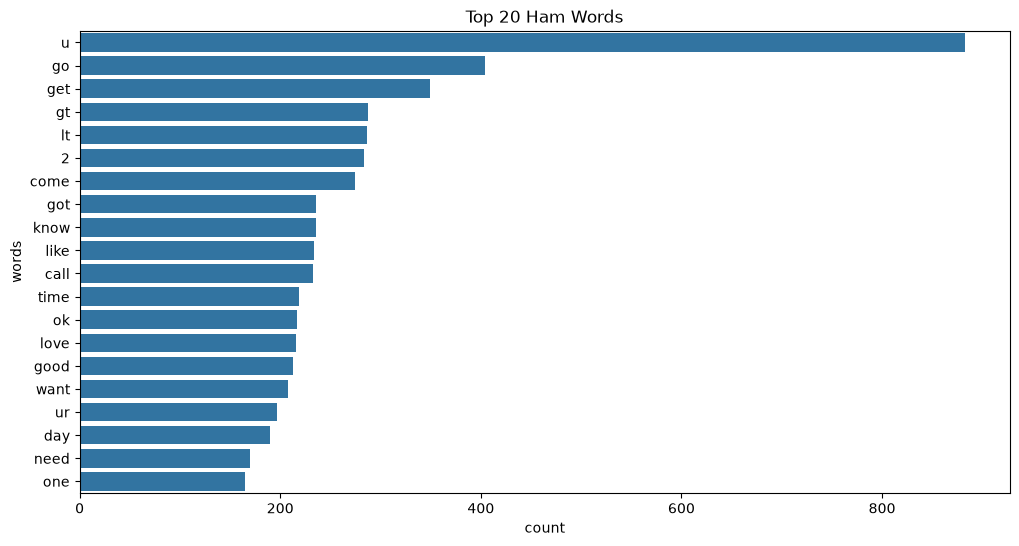

In [95]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.barplot(
    x='count',
    y='words',
    data=ham_df
)

plt.title("Top 20 Ham Words")
plt.show()

In [97]:
feature_names = tfidf.get_feature_names_out()
print(feature_names[:20])

['0207' '02073162414' '021' '07123456789' '0776xxxxxxx' '07xxxxxxxxx'
 '0800' '08000407165' '08000776320' '08000839402' '08000930705'
 '08000938767' '08001950382' '08002888812' '08002986906' '0844' '0845'
 '08452810073' '0870' '08700621170150p']


In [98]:
len(feature_names)

3000

In [100]:
input_text = "COngratulations!! You won a free iPhone. Claim now!"
transformed = transform_text(input_text)
vector = tfidf.transform([transformed])
vector.shape

(1, 3000)

In [101]:
import numpy as np
indices = np.argsort(vector.toarray()[0])[::-1]
indices[:10]

array([ 720,  677, 1158, 2976,   15,   16, 2991,    0, 2995,   30])

In [102]:
top_words = []

for idx in indices[:10]:
    if vector.toarray()[0][idx] > 0:
        top_words.append(feature_names[idx])

top_words

['congratul', 'claim', 'free']

In [107]:
def explain_prediction(text):
    
    transformed = transform_text(text)

    vector = tfidf.transform([transformed])

    feature_names = tfidf.get_feature_names_out()

    indices = np.argsort(vector.toarray()[0])[::-1]

    top_words = []

    for idx in indices[:10]:
        if vector.toarray()[0][idx] > 0:
            top_words.append(feature_names[idx])

    return top_words

In [108]:
explain_prediction("Congratulations! You won a free iPhone. Claim now!")

['congratul', 'claim', 'free']

In [109]:
explain_prediction("Hey Khushi!, are you free for class tomorrow?")

['class', 'tomorrow', 'hey', 'free']